### *1. Ising chain*

ED                  time=0.245s    E_0/L=-1.27528715
basis0    5         time=0.075s    E_0/L=-1.30960828   status=optimal 
basis1    13        time=0.493s    E_0/L=-1.28215587   status=optimal 
basis2    25        time=1.539s    E_0/L=-1.27900114   status=optimal 
basis3    49        time=4.600s    E_0/L=-1.27668732   status=optimal 
basis4    130       time=53.563s   E_0/L=-1.27551030   status=optimal 


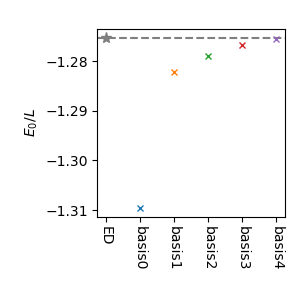

In [1]:
%reset -f
from ed.ising import gs as ed_gs
from compiler.ising import IsingParams, IsingCompiler, build_basis_reprs
from sdp import SDPSolver

import time
import matplotlib.pyplot as plt
%matplotlib widget

def bootstrap_gs(L, J, h, basis, eps=1e-4, max_iters=5000):
    compiler = IsingCompiler(IsingParams(L=L, J=J, h=h))
    compiler.compile(build_basis_reprs(L, basis))
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(backend='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 16
J = 1.
h = 1.

basis0 = ['I', 'X', 'Y', 'Z', 'ZZ']
basis1 = basis0 + ['XX', 'YY', 'XZ', 'XY', 'YX', 'YZ', 'ZX', 'ZY']
basis2 = basis1 + ['X'+b+c for b in 'XYZI' for c in 'XYZ']
basis3 = basis1 + [a+b+c for a in 'XYZ' for b in 'XYZI' for c in 'XYZ']
basis4 = basis3 + [a+b+c+d for a in 'XYZ' for b in 'XYZ' for c in 'XYZ' for d in 'XYZ']
bases = {
    'basis0': basis0,
    'basis1': basis1,
    'basis2': basis2,
    'basis3': basis3,
    'basis4': basis4,
}
eps = 1e-4
max_iters = 5_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, J=J, h=h)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{"":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f"E_0/L={e0:.8f}":<15s}'
)
ax.plot(['ED'], [e0], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0, color='tab:grey', linestyle='dashed')

for name, basis in bases.items():
    print(
        f'{name:<10s}'
        f'{len(basis):<10d}',
        end=''
    )
    t0 = time.perf_counter()
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        L, J, h, basis, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower:.8f}":<20s}'
        f'{"status=" + solver_summary["status"]:<15s}'
    )
    ax.plot([name], [e0_lower], marker='x', markersize=5, markerfacecolor='none')

ax.tick_params(axis='x', labelrotation=270)
ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()

### *2. Hubbard chain*

ED                  time=2.574s    E_0/L=-1.58343226
d4s1d0    16        time=0.124s    E_0/L=-1.67828494   status=optimal 
d2s2d1    27        time=0.532s    E_0/L=-1.68887821   status=optimal 
d2s2d2    43        time=1.430s    E_0/L=-1.67276170   status=optimal 
d2s2d3    59        time=3.301s    E_0/L=-1.64140971   status=optimal 
d2s2d4    75        time=4.576s    E_0/L=-1.63282145   status=optimal 
d2s2d5    85        time=5.340s    E_0/L=-1.62951095   status=optimal 
d3s2d1    79        time=5.472s    E_0/L=-1.61232562   status=optimal 
d3s2d2    143       time=65.234s   E_0/L=-1.60039765   status=optimal 
d3s2d3    207       time=213.391s  E_0/L=-1.59399609   status=optimal 


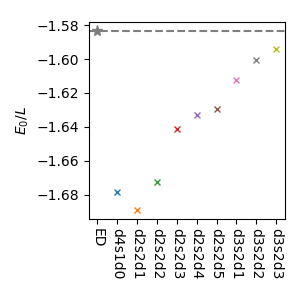

In [2]:
%reset -f
from ed.hubbard import gs as ed_gs
from compiler.hubbard import HubbardParams, HubbardCompiler, build_basis_reprs
from sdp import SDPSolver

import time
import matplotlib.pyplot as plt
%matplotlib widget

def bootstrap_gs(params, basis_reprs, eps=1e-4, max_iters=5000):
    compiler = HubbardCompiler(params)
    compiler.compile(basis_reprs)
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(backend='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 10
t = 1.
U = 4.
n_particles = L
params = HubbardParams(L=L, t=t, U=U, n_particles=n_particles)

bases = {
    'd4s1d0': build_basis_reprs(L, max_degree=4, max_support=1, max_diameter=0),
    'd2s2d1': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=1),
    'd2s2d2': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=2),
    'd2s2d3': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=3),
    'd2s2d4': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=4),
    'd2s2d5': build_basis_reprs(L, max_degree=2, max_support=2, max_diameter=5),
    'd3s2d1': build_basis_reprs(L, max_degree=3, max_support=2, max_diameter=1),
    'd3s2d2': build_basis_reprs(L, max_degree=3, max_support=2, max_diameter=2),
    'd3s2d3': build_basis_reprs(L, max_degree=3, max_support=2, max_diameter=3),
}
eps = 1e-4
max_iters = 5_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, t=t, U=U, n_particles=n_particles)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{"":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f"E_0/L={e0:.8f}":<15s}'
)
ax.plot(['ED'], [e0], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0, color='tab:grey', linestyle='dashed')

for name, basis_reprs in bases.items():
    print(
        f'{name:<10s}'
        f'{len(basis_reprs):<10d}',
        end=''
    )
    t0 = time.perf_counter()
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        params, basis_reprs, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower:.8f}":<20s}'
        f'{"status=" + solver_summary["status"]:<15s}'
    )
    ax.plot([name], [e0_lower], marker='x', markersize=5, markerfacecolor='none')

ax.tick_params(axis='x', labelrotation=270)
ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()